In [1]:
import os
import pandas as pd
from datetime import datetime
from os.path import abspath
# print(abspath('../example_dataset/'))

from starmap.config import Config
from starmap.pipeline import Pipeline
# from starmap import io as io
# from starmap import cell_segmentation as cellseg

2024-04-25 16:07:21.324339: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-25 16:07:21.362158: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-25 16:07:21.983244: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
config = Config(filepath_homedir = abspath("../../example_dataset/")+"/",
                filepath_rawdata = "",
                filepath_codebook = abspath('../../example_dataset/')+"/"+"Acan_classB_11geneset_GFP_barcodes.csv",
                filepath_dapi_all_z = "",
                filepath_dapi = "",
                filepath_nissl = "",
                round_index = [1, 2, 3, 4],
                fov_num = 3,
                fov_align = 1,
                fov_minmax = [0, 1, 2],
                nogene_keyword = 'no_gene',
                cellpose_model = 'cyto',
                cellpose_channel = [0, 1],
                radius = 10,
                expand_pixel = 15,
                ifov = 1,
                igenes = ["Slc17a6", "Gad1", "Acan", "GFP", "nogene1", "nogene2"],
                SpGene = "Finished", # 'ChAlign', 'RoAlign', 'CbCorrection', 'Normalization', 'bardensrReg', 'GeneCalling', 'Finished'
                SpMask = "Finished", # 'PosReg', 'CellSeg', 'ExpMask', 'Gene2Mask', 'RmvOverlap', 'Finished'
                grid_stitch = True,
                bardensr_reg = True,
                find_param = True,
                cellpose_denoise = False,
                remove_overlap = True
                )

2024-04-25 16:07:26.443266: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /device:GPU:0 with 46046 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [3]:
pipeline = Pipeline(config)

25/04/2024 16:07:30 restart the pipeline from some point
25/04/2024 16:07:30 ----reload dapi/nissl images
25/04/2024 16:07:30 ----reload dapi/nissl images
25/04/2024 16:07:30 ----reload intermediate data for gene calling
25/04/2024 16:07:31         genenames:  ['Acan', 'Fnbp1l', 'GFP', 'Gad1', 'Gfap', 'Pdgfra', 'Slc17a6', 'Slc6a1', 'Slc6a5', 'Sv2c', 'Tmem119', 'no_genetdTomato', 'no_gene1', 'no_gene2']
25/04/2024 16:07:31         gene_codes:  [array(['T', 'A', 'G', 'A'], dtype='<U1'), array(['A', 'A', 'A', 'G'], dtype='<U1'), array(['C', 'C', 'G', 'G'], dtype='<U1'), array(['T', 'T', 'A', 'C'], dtype='<U1'), array(['G', 'C', 'T', 'A'], dtype='<U1'), array(['T', 'C', 'T', 'C'], dtype='<U1'), array(['C', 'A', 'C', 'C'], dtype='<U1'), array(['G', 'T', 'G', 'C'], dtype='<U1'), array(['A', 'T', 'A', 'C'], dtype='<U1'), array(['A', 'C', 'G', 'T'], dtype='<U1'), array(['C', 'G', 'A', 'G'], dtype='<U1'), array(['C', 'T', 'C', 'G'], dtype='<U1'), array(['A', 'G', 'A', 'A'], dtype='<U1'), array(

In [ ]:
pipeline.run()

if config.CpMask['RmvOverlap'] and config.remove_overlap:
    if config.grid_stitch:
        os.system('python remove_overlap_mp.py ' + config.filepath_homedir + ' position_reg ' + str(config.dim))
    else:
        os.system('python remove_overlap_mp.py ' + config.filepath_homedir + ' position_corr ' + str(config.dim))
    # os.system('python remove_overlap_mp.py %s' % config.filepath_homedir)

pipeline.validation()
pipeline.save()

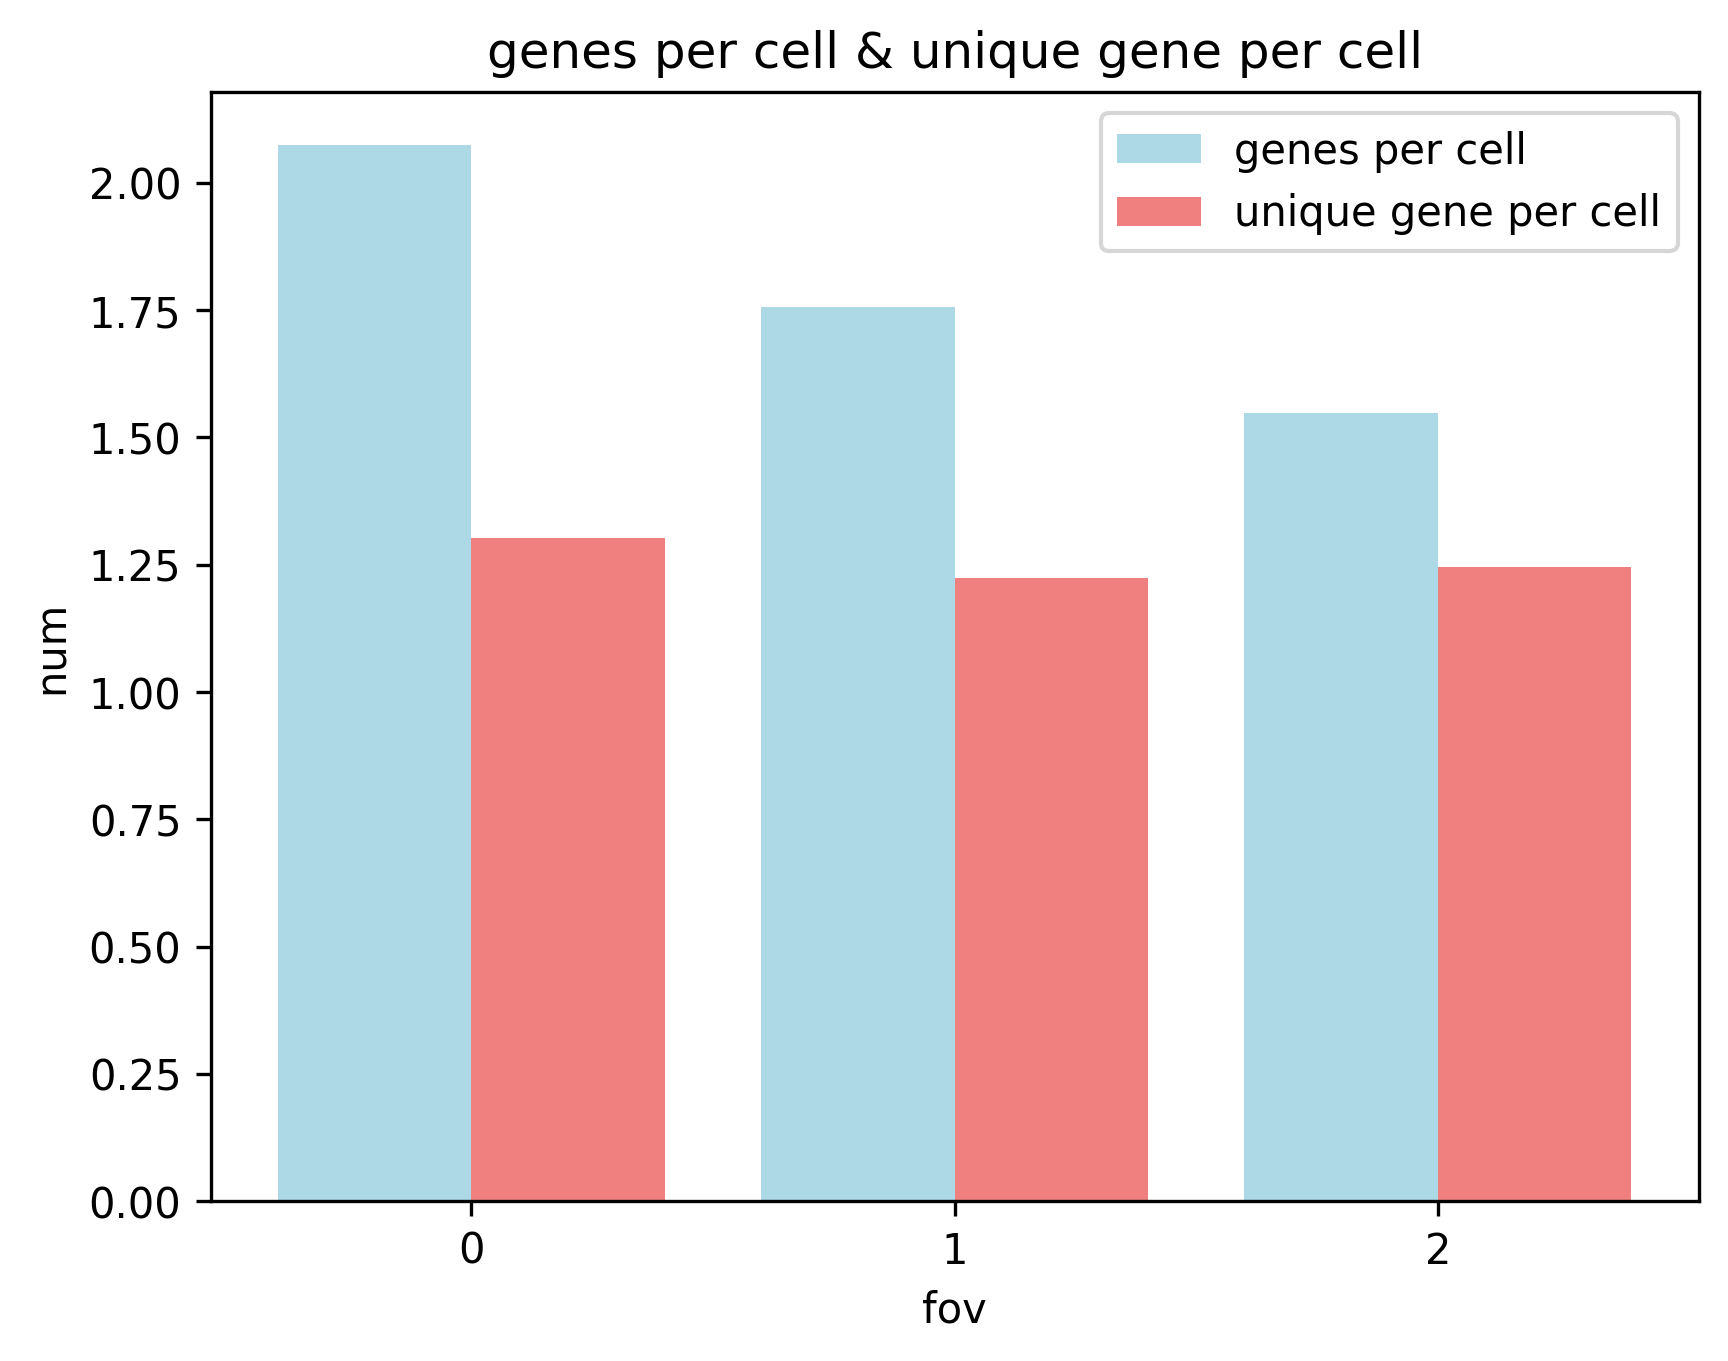

In [8]:
import matplotlib.pyplot as plt
import numpy as np
def plot_gene_per_cell(config):
    gene_mapped = pd.read_csv(config.filepath_output+'gene_mapped.csv')
    
    gene2cell_fov, unigene2cell_fov = [], []
    for FOV in range(config.fov_num):
        gene_fov = gene_mapped[gene_mapped['FOV']==FOV]
        gene_cell, unigene_cell = [], []
        for CELL in np.unique(gene_fov['cell_number']):
            temp = gene_fov[gene_fov['cell_number']==CELL]
            gene_cell.append(len(temp))
            unigene_cell.append(len(np.unique(temp['Names'])))
        gene2cell_fov.append(np.average(gene_cell))
        unigene2cell_fov.append(np.average(unigene_cell))
    plt.figure()
    if int(config.fov_num*0.2) >5: plt.figure(figsize=(int(config.fov_num*0.2)*2, int(config.fov_num*0.2)))
    bar1 = plt.bar(x=np.arange(config.fov_num), height=gene2cell_fov, width=0.4, label='genes per cell', color='lightblue', tick_label=range(config.fov_num))
    bar2 = plt.bar(x=np.arange(config.fov_num)+0.4, height=unigene2cell_fov, width=0.4, label='unique gene per cell', color='lightcoral')
    # plt.bar_label(bar1)
    # plt.bar_label(bar2)
    plt.title('genes per cell & unique gene per cell')
    plt.xlabel('fov')
    plt.ylabel('num')
    plt.xticks(np.arange(config.fov_num)+0.2, range(config.fov_num))
    plt.legend()

plot_gene_per_cell(config)

In [5]:
pipeline.config.thresh_refined

nan